<a href="https://colab.research.google.com/github/manasivinod/NorthStar-Analytics/blob/main/Python_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pymongo --quiet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("✅ Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 22.6 MB/s eta 0:00:00
✅ Done!


In [2]:
BASE = "https://raw.githubusercontent.com/manasivinod/NorthStar-Analytics/main/"

hubs       = pd.read_csv(BASE + "hubs.csv")
customers  = pd.read_csv(BASE + "customers.csv")
drivers    = pd.read_csv(BASE + "drivers.csv")
vehicles   = pd.read_csv(BASE + "vehicles.csv")
orders     = pd.read_csv(BASE + "orders.csv")
deliveries = pd.read_csv(BASE + "deliveries.csv")
incidents  = pd.read_csv(BASE + "incidents.csv")
complaints = pd.read_csv(BASE + "complaints.csv")
app_events = pd.read_csv(BASE + "app_events.csv")

print("Loaded:")
for name, df in [("hubs",hubs),("customers",customers),("drivers",drivers),
                  ("vehicles",vehicles),("orders",orders),("deliveries",deliveries),
                  ("incidents",incidents),("complaints",complaints),("app_events",app_events)]:
    print(f"  {name}: {len(df)} rows")

Loaded:
  hubs: 8 rows
  customers: 650 rows
  drivers: 170 rows
  vehicles: 120 rows
  orders: 1250 rows
  deliveries: 950 rows
  incidents: 280 rows
  complaints: 320 rows
  app_events: 640 rows


In [3]:
for df in [customers, hubs, orders, vehicles, drivers, app_events]:
    for col in ['home_zone','zone','pickup_zone','dropoff_zone',
                'assigned_zone','base_zone','zone_context']:
        if col in df.columns:
            df[col] = df[col].str.strip().str.title()
print("=== Missing Values ===")
for name, df in [("orders",orders),("deliveries",deliveries),
                  ("complaints",complaints),("incidents",incidents)]:
    m = df.isnull().sum()
    m = m[m > 0]
    if len(m):
        print(f"\n{name}:\n{m}")
    else:
        print(f"{name}: no missing values ✅")

=== Missing Values ===

orders:
booking_channel    25
dtype: int64

deliveries:
delivery_completed_at            19
customer_rating_post_delivery    14
dtype: int64

complaints:
compensation_amount    16
dtype: int64

incidents:
resolved_hours    17
dtype: int64


In [4]:
deliveries['dispatch_time']         = pd.to_datetime(deliveries['dispatch_time'], errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')
orders['order_created_at']          = pd.to_datetime(orders['order_created_at'], errors='coerce')

del_ord = deliveries.merge(
    orders[['order_id','promised_window_hours','service_type',
            'pickup_zone','dropoff_zone','order_value']],
    on='order_id', how='left'
)

del_ord['actual_hours'] = (
    del_ord['delivery_completed_at'] - del_ord['dispatch_time']
).dt.total_seconds() / 3600

del_ord['delay_hours'] = del_ord['actual_hours'] - del_ord['promised_window_hours']

del_ord['is_late'] = (del_ord['delay_hours'] > 0).astype(int)

del_ord['cost_per_km'] = (del_ord['fuel_or_charge_cost'] / del_ord['route_distance_km']).round(3)

del_ord = del_ord[del_ord['actual_hours'] >= 0]

print(f"✅ Feature engineering done")
print(f"   Total deliveries: {len(del_ord)}")
print(f"   Late deliveries:  {del_ord['is_late'].sum()} ({del_ord['is_late'].mean()*100:.1f}%)")
print(del_ord[['delivery_id','delivery_status','actual_hours','delay_hours','is_late','cost_per_km']].head(6))

✅ Feature engineering done
   Total deliveries: 867
   Late deliveries:  435 (50.2%)
  delivery_id delivery_status  actual_hours  delay_hours  is_late  cost_per_km
0     DL00001          Failed     22.149973    16.149973        1        0.698
2     DL00003          OnTime      1.108991    -0.891009        0        1.074
3     DL00004         Delayed     23.985584    -0.014416        0        0.829
4     DL00005          OnTime      4.042814    -1.957186        0        0.635
5     DL00006         Delayed     28.531218     4.531218        1        0.692
6     DL00007         Delayed     33.969742     9.969742        1        0.541


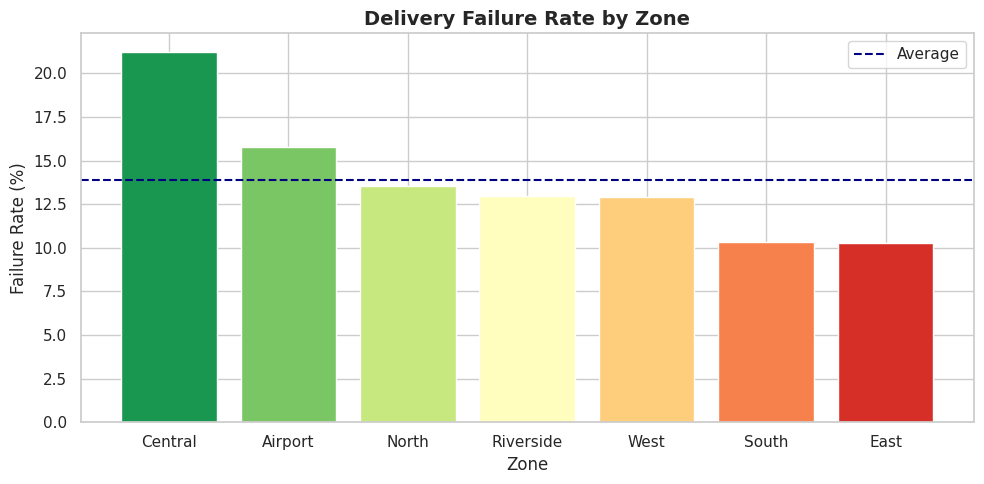

     zone  total  failed  failure_pct
  Central    226      48        21.24
  Airport     95      15        15.79
    North    118      16        13.56
Riverside    108      14        12.96
     West    116      15        12.93
    South     97      10        10.31
     East    107      11        10.28


In [5]:
del_hub = del_ord.merge(hubs[['hub_id','hub_name','zone']], on='hub_id', how='left')

zone_stats = del_hub.groupby('zone').agg(
    total     = ('delivery_id','count'),
    failed    = ('delivery_status', lambda x: (x=='Failed').sum())
).reset_index()
zone_stats['failure_pct'] = (zone_stats['failed'] / zone_stats['total'] * 100).round(2)
zone_stats = zone_stats.sort_values('failure_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(zone_stats['zone'], zone_stats['failure_pct'],
              color=plt.cm.RdYlGn_r(np.linspace(0.1,0.9,len(zone_stats))),
              edgecolor='white')
ax.axhline(zone_stats['failure_pct'].mean(), color='navy',
           linestyle='--', linewidth=1.5, label='Average')
ax.set_title('Delivery Failure Rate by Zone', fontsize=14, fontweight='bold')
ax.set_xlabel('Zone')
ax.set_ylabel('Failure Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

print(zone_stats.to_string(index=False))

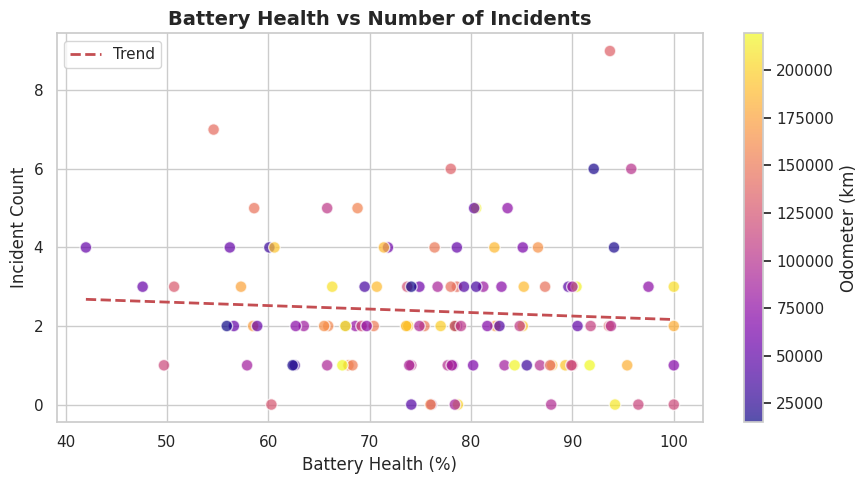

In [6]:
veh_inc = incidents.merge(
    deliveries[['delivery_id','vehicle_id']], on='delivery_id', how='left'
).groupby('vehicle_id').size().reset_index(name='incident_count')

veh = vehicles.merge(veh_inc, on='vehicle_id', how='left')
veh['incident_count'] = veh['incident_count'].fillna(0)

veh['battery_health_pct'] = pd.to_numeric(veh['battery_health_pct'], errors='coerce')
veh['incident_count'] = pd.to_numeric(veh['incident_count'], errors='coerce')
veh['odometer_km'] = pd.to_numeric(veh['odometer_km'], errors='coerce')

veh_plot = veh[['battery_health_pct', 'incident_count', 'odometer_km']].replace(
    [np.inf, -np.inf], np.nan
).dropna()

fig, ax = plt.subplots(figsize=(9,5))

sc = ax.scatter(
    veh_plot['battery_health_pct'],
    veh_plot['incident_count'],
    c=veh_plot['odometer_km'],
    cmap='plasma',
    alpha=0.7,
    s=70,
    edgecolors='white'
)

plt.colorbar(sc, ax=ax, label='Odometer (km)')

if len(veh_plot) >= 2 and veh_plot['battery_health_pct'].nunique() > 1:
    z = np.polyfit(veh_plot['battery_health_pct'], veh_plot['incident_count'], 1)
    xline = np.linspace(
        veh_plot['battery_health_pct'].min(),
        veh_plot['battery_health_pct'].max(),
        100
    )
    ax.plot(xline, np.poly1d(z)(xline), 'r--', linewidth=2, label='Trend')

ax.set_title('Battery Health vs Number of Incidents', fontsize=14, fontweight='bold')
ax.set_xlabel('Battery Health (%)')
ax.set_ylabel('Incident Count')
ax.legend()
plt.tight_layout()
plt.show()

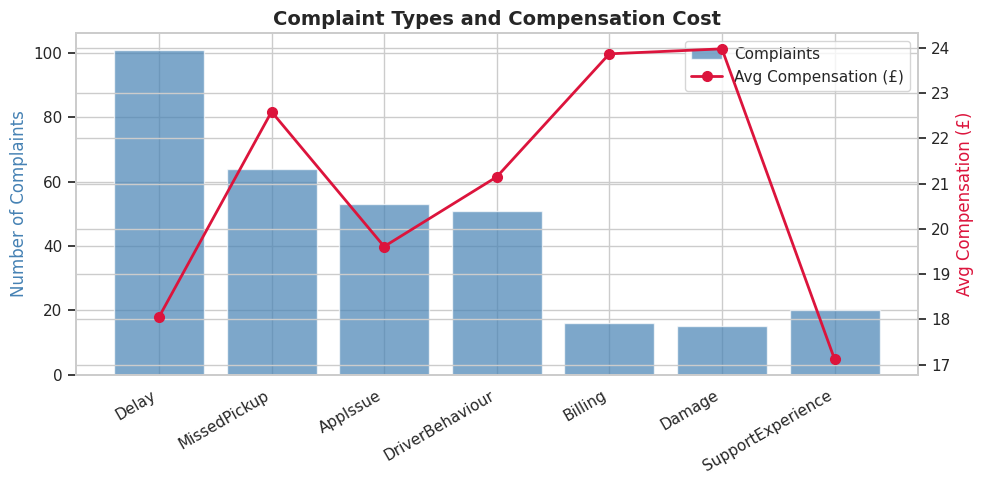

   complaint_type  count  avg_comp  total_comp
            Delay    101     18.05     1696.84
     MissedPickup     64     22.59     1423.40
         AppIssue     53     19.61      980.72
  DriverBehaviour     51     21.15      973.06
          Billing     16     23.87      381.94
           Damage     15     23.98      359.73
SupportExperience     20     17.12      342.50


In [7]:
comp_type = complaints.groupby('complaint_type').agg(
    count          = ('complaint_id','count'),
    avg_comp       = ('compensation_amount','mean'),
    total_comp     = ('compensation_amount','sum')
).round(2).reset_index().sort_values('total_comp', ascending=False)

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

x = range(len(comp_type))
ax1.bar(x, comp_type['count'], color='steelblue', alpha=0.7, label='Complaints')
ax2.plot(x, comp_type['avg_comp'], color='crimson', marker='o',
          linewidth=2, markersize=7, label='Avg Compensation (£)')

ax1.set_xticks(list(x))
ax1.set_xticklabels(comp_type['complaint_type'], rotation=30, ha='right')
ax1.set_ylabel('Number of Complaints', color='steelblue')
ax2.set_ylabel('Avg Compensation (£)', color='crimson')
ax1.set_title('Complaint Types and Compensation Cost', fontsize=14, fontweight='bold')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2)
plt.tight_layout()
plt.show()

print(comp_type.to_string(index=False))

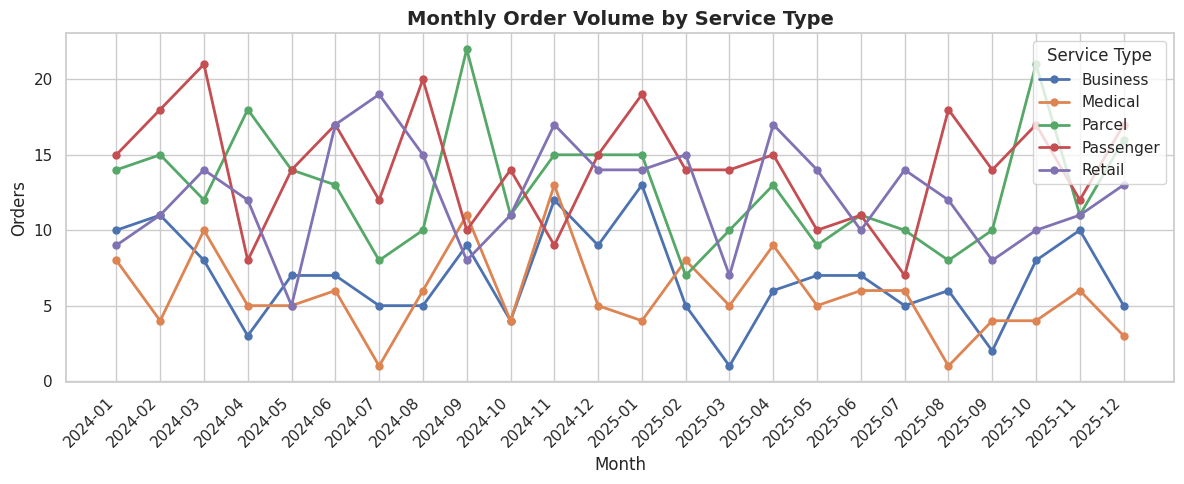

In [8]:
orders['month'] = orders['order_created_at'].dt.to_period('M')
monthly = orders.groupby(['month','service_type']).size().reset_index(name='count')
monthly['month_str'] = monthly['month'].astype(str)

fig, ax = plt.subplots(figsize=(12,5))
for stype, grp in monthly.groupby('service_type'):
    ax.plot(grp['month_str'], grp['count'], marker='o', linewidth=2, markersize=5, label=stype)

ax.set_title('Monthly Order Volume by Service Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Orders')
ax.legend(title='Service Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

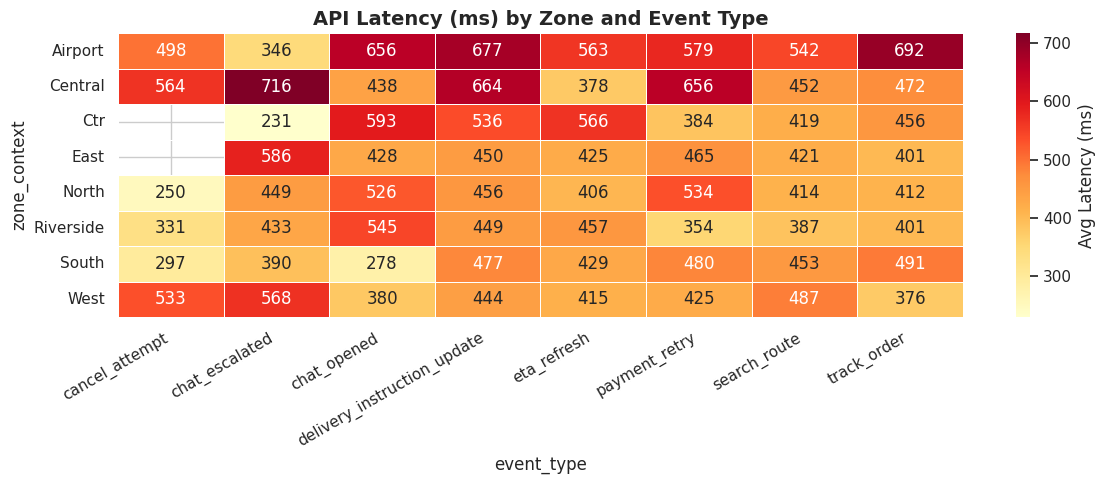

In [9]:
app_events['zone_context'] = app_events['zone_context'].str.strip().str.title()

pivot = app_events.groupby(['zone_context','event_type'])['api_latency_ms'].mean().unstack()

fig, ax = plt.subplots(figsize=(12,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Avg Latency (ms)'})
ax.set_title('API Latency (ms) by Zone and Event Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

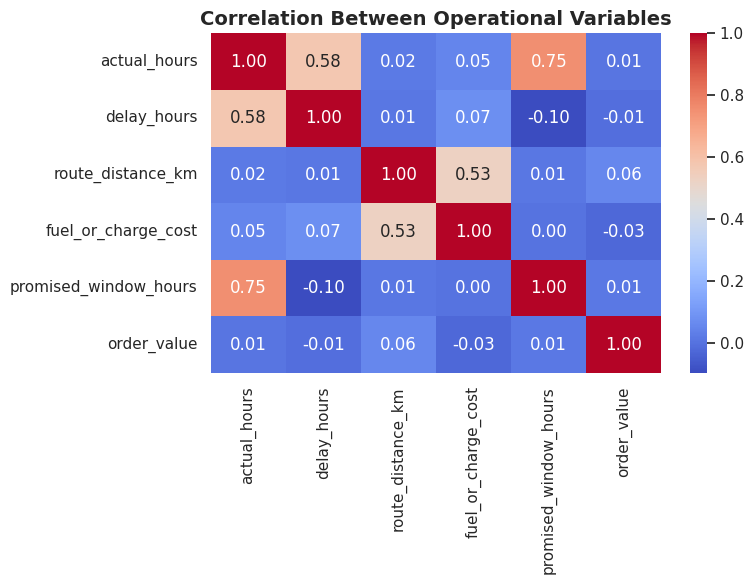

In [10]:
corr_data = del_ord[[
    'actual_hours',
    'delay_hours',
    'route_distance_km',
    'fuel_or_charge_cost',
    'promised_window_hours',
    'order_value'
]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_data,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Correlation Between Operational Variables',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

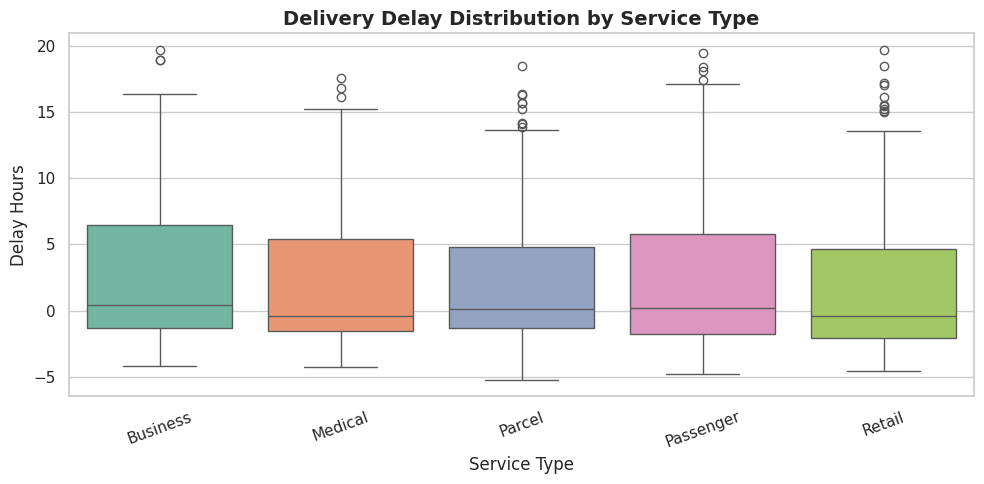

In [11]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=del_ord,
    x='service_type',
    y='delay_hours',
    palette='Set2'
)

plt.title(
    'Delivery Delay Distribution by Service Type',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Service Type')
plt.ylabel('Delay Hours')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [12]:
threshold = (
    del_ord['delay_hours'].mean()
    + 2 * del_ord['delay_hours'].std()
)

anomalies = del_ord[
    del_ord['delay_hours'] > threshold
]

print("Extreme Delay Cases:")

print(anomalies[[
    'delivery_id',
    'hub_id',
    'service_type',
    'delay_hours'
]].head(10))

Extreme Delay Cases:
    delivery_id hub_id service_type  delay_hours
0       DL00001    H05     Business    16.149973
25      DL00026    H04    Passenger    14.546064
32      DL00033    H06      Medical    16.840334
33      DL00034    H04      Medical    15.232515
39      DL00040    H04       Retail    15.443134
77      DL00078    H02    Passenger    17.146994
83      DL00084    H05    Passenger    16.326482
96      DL00097    H07       Retail    15.021504
102     DL00103    H04    Passenger    14.637739
118     DL00119    H03     Business    18.981215
